
MAXIMUM LIKELIHOOD ANALYSIS (PD, PA)  [mu = mu[i] from COLUMN]
Energy cut applied: 15.0-60.0 keV

Exposure summary:
  total_exp_on  = 48822.91 s
  total_exp_off = 15371.35 s

Data summary (after your cut):
  nOn  = 86,356
  nOff = 15,306
  tOn  = 48822.9 s
  tOff = 15371.3 s

fractions:
  scale = tOn/tOff = 3.1762
  nS ≈ 37,740.7
  nB ≈ 48,615.3
  xiS = 0.437036
  xiB = 0.562964

Subsample disabled: using ALL ON events for grid scan.

Running coarse grid scan...
Coarse best-fit:
  PD ≈ 24.00%
  PA ≈ 132.00 deg

Running fine grid scan...
  PD range: 21.00% to 27.00%  step 0.10%
  PA range: 122.00 deg to 142.00 deg  step 0.50 deg

ML best-fit (fine scan):
  PD_hat = 23.80%
  PA_hat = 131.50 deg
  lnL_max = 4.384741e+01


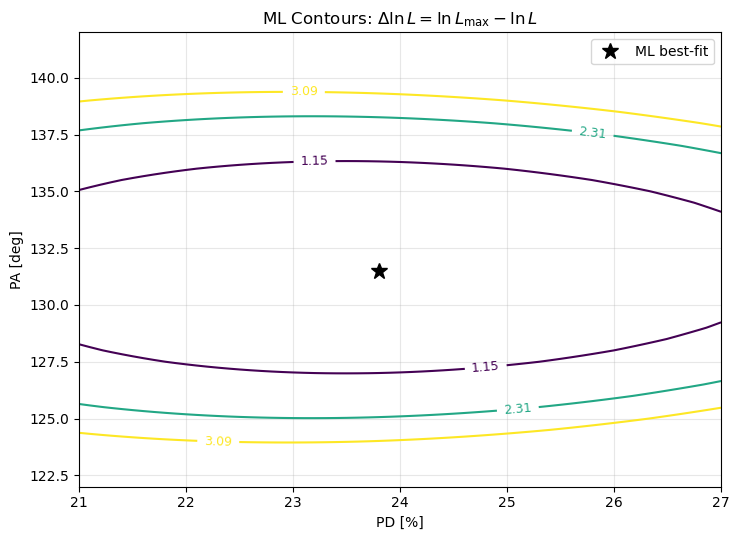


Done.


In [49]:
# -*- coding: utf-8 -*-
"""
Maximum likelihood (PD, PA) — SAME steps as your notebook version,
but with event-level mu[i] via mapping from FITS COLUMN (1..32) -> mu_table[row].

This script:
1) Reads ON/OFF event files
2) Builds phi = 0.5*atan2(U,Q) and maps to [0, pi)
3) Builds mu[i] from COLUMN
4) Reads total exposures from EVENTS header['EXPOSURE'] for ALL files
5) Estimates xiS/xiB from ON/OFF counts + exposures (same formula as your notebook)
6) Coarse -> Fine grid scan
7) Makes contour plot with Wilks levels (same as your notebook)

Only "new" physics: mu is per-event (mu_used array), everything else matches your cell.
"""

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

print("\n" + "="*70)
print("MAXIMUM LIKELIHOOD ANALYSIS (PD, PA)  [mu = mu[i] from COLUMN]")
print("="*70)

# =========================
# FILES (edit if needed)
# =========================
on_files = [
    '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pon_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010003/event/xl2024010003_pon_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010004/event/xl2024010004_pon_cl.evt.gz',
]

off_files = [
    '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pof_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010003/event/xl2024010003_pof_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010004/event/xl2024010004_pof_cl.evt.gz',
]

EVENTS_HDU = "EVENTS"

# =========================
# Settings  (match your notebook)
# =========================
USE_WEIGHTS   = False      # True: sum(w * ln p_i), False: sum(ln p_i)
USE_SUBSAMPLE = True       # True: speed up grid scan
N_SAMPLE      = 200000     # subsample size for ON events (adjust if needed)
RANDOM_SEED   = 0

# Grid settings (two-stage scan: coarse -> fine)  (match your notebook)
PD_MIN, PD_MAX = 0.0, 0.30
PA_MIN, PA_MAX = 0.0, np.pi

PD_STEP_COARSE = 0.005     # coarse PD step
PA_STEP_COARSE_DEG = 2.0   # coarse PA step (deg)

PD_HALF_WINDOW_FINE = 0.03      # +/- around best PD
PA_HALF_WINDOW_FINE_DEG = 10.0  # +/- around best PA (deg)
PD_STEP_FINE = 0.001
PA_STEP_FINE_DEG = 0.5

# Numerical safety (match your notebook)
EPS = 1e-12


# Columns in your EVT (confirmed)

COL_Q      = "Q"
COL_U      = "U"
COL_PI     = "PI"
COL_W      = "WEIGHT"
COL_COLUMN = "Z_LAYER"   # 1..32 (this is your "row" for mu mapping)


# Energy cut
# If you want EXACT alignment with your notebook cell, set these to same values there.
# Keep as None to disable.
ENERGY_MIN_KEV = 15.0
ENERGY_MAX_KEV = 60.0

PI_min = int(ENERGY_MIN_KEV / 0.1)
PI_max = int(ENERGY_MAX_KEV / 0.1)

m_on  = (PI_on  >= PI_min) & (PI_on  <= PI_max)
m_off = (PI_off >= PI_min) & (PI_off <= PI_max)

PI_on  = PI_on[m_on]
PI_off = PI_off[m_off]

phi_on  = phi_on[m_on]
phi_off = phi_off[m_off]

if 'column_on' in locals():
    column_on  = column_on[m_on]
if 'column_off' in locals():
    column_off = column_off[m_off]

print(f"Energy cut applied: {ENERGY_MIN_KEV}-{ENERGY_MAX_KEV} keV")

# mu_table (row -> mu) keys 1..32

mu_table = {
     1: 0.34,  2: 0.36,  3: 0.42,  4: 0.49,  5: 0.55,  6: 0.545,  7: 0.53,  8: 0.50,
     9: 0.48, 10: 0.47, 11: 0.46, 12: 0.45, 13: 0.425, 14: 0.42, 15: 0.438, 16: 0.40,
    17: 0.36, 18: 0.42, 19: 0.39, 20: 0.41, 21: 0.39, 22: 0.40, 23: 0.38, 24: 0.337,
    25: 0.34, 26: 0.38, 27: 0.40, 28: 0.39, 29: 0.363, 30: 0.364, 31: 0.43, 32: 0.317
}


# Exposure: sum EVENTS header['EXPOSURE'] across files

def get_total_exposure(file_list):
    total_exp = 0.0
    for fp in file_list:
        with fits.open(fp) as hdul:
            hdr = hdul[EVENTS_HDU].header
            total_exp += float(hdr.get("EXPOSURE", 0.0))
    return total_exp


# FITS reader: returns arrays for ON/OFF
# We need Q/U -> phi, plus COLUMN -> mu[i]. Off arrays are only used for counts.

def read_evt_arrays(file_list):
    Q_all, U_all, col_all, w_all, pi_all = [], [], [], [], []
    for fp in file_list:
        with fits.open(fp) as hdul:
            tab = hdul[EVENTS_HDU].data
            Q_all.append(np.array(tab[COL_Q], dtype=float))
            U_all.append(np.array(tab[COL_U], dtype=float))
            col_all.append(np.array(tab[COL_COLUMN], dtype=int))   # 1..32
            w_all.append(np.array(tab[COL_W], dtype=float))
            pi_all.append(np.array(tab[COL_PI], dtype=float))

    Q_all = np.concatenate(Q_all) if Q_all else np.array([], dtype=float)
    U_all = np.concatenate(U_all) if U_all else np.array([], dtype=float)
    col_all = np.concatenate(col_all) if col_all else np.array([], dtype=int)
    w_all = np.concatenate(w_all) if w_all else np.array([], dtype=float)
    pi_all = np.concatenate(pi_all) if pi_all else np.array([], dtype=float)
    return Q_all, U_all, col_all, w_all, pi_all


# Read ON/OFF

Q_on, U_on, col_on, weight_on, PI_on = read_evt_arrays(on_files)
Q_off, U_off, col_off, weight_off, PI_off = read_evt_arrays(off_files)


# Build phi for ON/OFF: phi = 0.5*atan2(U, Q) in [0, pi)

phi_on = 0.5 * np.arctan2(U_on, Q_on)
phi_on = np.mod(phi_on, np.pi)   # [0, pi)

phi_off = 0.5 * np.arctan2(U_off, Q_off)
phi_off = np.mod(phi_off, np.pi) # [0, pi)


# Build mu[i] via COLUMN -> mu_table (new)
mu_on  = np.array([mu_table.get(int(r), 0.0) for r in col_on], dtype=float)   # r = 1..32
mu_off = np.array([mu_table.get(int(r), 0.0) for r in col_off], dtype=float)


# Exposures

total_exp_on  = get_total_exposure(on_files)
total_exp_off = get_total_exposure(off_files)

print("\nExposure summary:")
print(f"  total_exp_on  = {total_exp_on:.2f} s")
print(f"  total_exp_off = {total_exp_off:.2f} s")


# Data summary + ON/OFF fractions

nOn = len(phi_on)
nOff = len(phi_off)
tOn = float(total_exp_on)
tOff = float(total_exp_off)

print(f"\nData summary (after your cut):")
print(f"  nOn  = {nOn:,}")
print(f"  nOff = {nOff:,}")
print(f"  tOn  = {tOn:.1f} s")
print(f"  tOff = {tOff:.1f} s")

scale = tOn / tOff if tOff > 0 else 0.0
nS = nOn - scale * nOff
nS = max(nS, 0.0)
nB = nOn - nS

xiS = np.clip(nS / nOn, 0.0, 1.0) if nOn > 0 else 0.0
xiB = 1.0 - xiS

print("\nfractions:")
print(f"  scale = tOn/tOff = {scale:.4f}")
print(f"  nS ≈ {nS:,.1f}")
print(f"  nB ≈ {nB:,.1f}")
print(f"  xiS = {xiS:.6f}")
print(f"  xiB = {xiB:.6f}")


# Subsample for speed (ON only, same as your notebook)
# IMPORTANT: if you subsample phi_on, you MUST subsample mu_on the same way.

if USE_SUBSAMPLE and nOn > N_SAMPLE:
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(nOn, size=N_SAMPLE, replace=False)
    phi_used = phi_on[idx]
    mu_used  = mu_on[idx]
    w_used = weight_on[idx] if USE_WEIGHTS else None
    print(f"\nSubsample enabled: using {N_SAMPLE:,} / {nOn:,} ON events for grid scan.")
else:
    phi_used = phi_on
    mu_used  = mu_on
    w_used = weight_on if USE_WEIGHTS else None
    print("\nSubsample disabled: using ALL ON events for grid scan.")


# Log-likelihood
#   ps = 1 + PD * mu_i * cos(2*(phi - PA))
#   pb = 1
#   p_i = xiS*ps + xiB*pb = 1 + (xiS*PD*mu_i)*cos(2*(phi-PA))

def loglike_PD_PA(phi, mu, PD, PA, xiS, weights=None):
    c = np.cos(2.0 * (phi - PA))
    k = xiS * PD * mu               # vector (per-event)
    p = 1.0 + k * c
    p = np.maximum(p, EPS)
    if weights is None:
        return float(np.sum(np.log(p)))
    else:
        return float(np.sum(weights * np.log(p)))

def scan_grid(phi, mu, xiS, PD_grid, PA_grid, weights=None):
    ll = np.empty((len(PD_grid), len(PA_grid)), dtype=float)
    for j, PA in enumerate(PA_grid):
        c = np.cos(2.0 * (phi - PA))
        for i, PD in enumerate(PD_grid):
            k = xiS * PD * mu
            p = 1.0 + k * c
            p = np.maximum(p, EPS)
            if weights is None:
                ll[i, j] = np.sum(np.log(p))
            else:
                ll[i, j] = np.sum(weights * np.log(p))
    return ll

# Coarse scan

PD_grid_coarse = np.arange(PD_MIN, PD_MAX + 0.5*PD_STEP_COARSE, PD_STEP_COARSE)
PA_grid_coarse = np.deg2rad(np.arange(0.0, 180.0 + 0.5*PA_STEP_COARSE_DEG, PA_STEP_COARSE_DEG))

print("\nRunning coarse grid scan...")
ll_coarse = scan_grid(phi_used, mu_used, xiS, PD_grid_coarse, PA_grid_coarse, weights=w_used)

imax = np.unravel_index(np.argmax(ll_coarse), ll_coarse.shape)
PD_best_coarse = PD_grid_coarse[imax[0]]
PA_best_coarse = PA_grid_coarse[imax[1]]

print("Coarse best-fit:")
print(f"  PD ≈ {PD_best_coarse*100:.2f}%")
print(f"  PA ≈ {np.degrees(PA_best_coarse):.2f} deg")


# Fine scan around coarse best-fit

PD_lo = max(PD_MIN, PD_best_coarse - PD_HALF_WINDOW_FINE)
PD_hi = min(PD_MAX, PD_best_coarse + PD_HALF_WINDOW_FINE)

PA_center_deg = np.degrees(PA_best_coarse)
PA_lo_deg = max(0.0, PA_center_deg - PA_HALF_WINDOW_FINE_DEG)
PA_hi_deg = min(180.0, PA_center_deg + PA_HALF_WINDOW_FINE_DEG)

PD_grid_fine = np.arange(PD_lo, PD_hi + 0.5*PD_STEP_FINE, PD_STEP_FINE)
PA_grid_fine = np.deg2rad(np.arange(PA_lo_deg, PA_hi_deg + 0.5*PA_STEP_FINE_DEG, PA_STEP_FINE_DEG))

print("\nRunning fine grid scan...")
print(f"  PD range: {PD_lo*100:.2f}% to {PD_hi*100:.2f}%  step {PD_STEP_FINE*100:.2f}%")
print(f"  PA range: {PA_lo_deg:.2f} deg to {PA_hi_deg:.2f} deg  step {PA_STEP_FINE_DEG:.2f} deg")

ll_fine = scan_grid(phi_used, mu_used, xiS, PD_grid_fine, PA_grid_fine, weights=w_used)

imax2 = np.unravel_index(np.argmax(ll_fine), ll_fine.shape)
PD_hat = PD_grid_fine[imax2[0]]
PA_hat = PA_grid_fine[imax2[1]]
ll_max = ll_fine[imax2]

print("\nML best-fit (fine scan):")
print(f"  PD_hat = {PD_hat*100:.2f}%")
print(f"  PA_hat = {np.degrees(PA_hat):.2f} deg")
print(f"  lnL_max = {ll_max:.6e}")


# Contour plot: ΔlnL = lnL_max - lnL 

dlnL = ll_max - ll_fine  # (nPD, nPA)

PD_mesh, PA_mesh = np.meshgrid(PD_grid_fine*100.0, np.degrees(PA_grid_fine), indexing="ij")

plt.figure(figsize=(7.5, 5.5))

levels = [1.15, 2.305, 3.09]
CS = plt.contour(PD_mesh, PA_mesh, dlnL, levels=levels)
plt.clabel(CS, inline=True, fontsize=9, fmt=lambda x: f"{x:.3g}")

plt.plot(PD_hat*100.0, np.degrees(PA_hat), "k*", markersize=12, label="ML best-fit")

plt.xlabel("PD [%]")
plt.ylabel("PA [deg]")
plt.title(r"ML Contours: $\Delta\ln L = \ln L_{\max}-\ln L$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone.")


In [24]:
#assign an event-dependent modulation factor μ_i using the detector row calibration table

In [31]:
col_on

array([13, 30, 30, ...,  5,  5, 19], shape=(86356,))

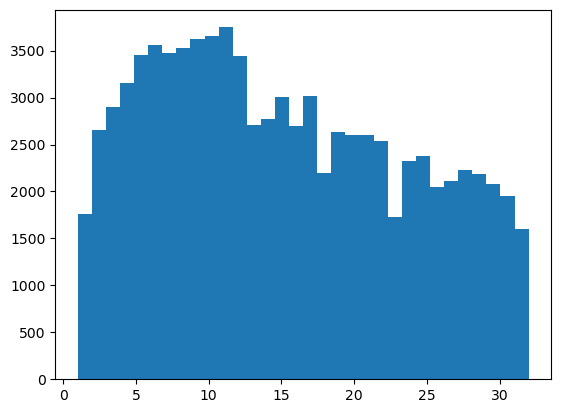

In [57]:
c1 = plt.hist(col_on,32)

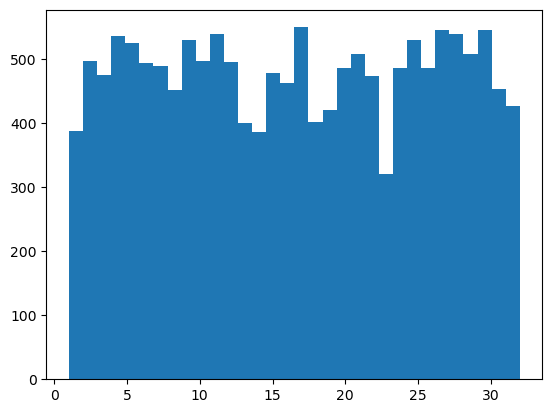

In [63]:
c2=plt.hist(col_off,32)

In [61]:
c1[0]-c2[0]

array([1759., 2659., 2895., 3153., 3453., 3558., 3472., 3529., 3619.,
       3658., 3749., 3443., 2709., 2777., 3007., 2693., 3020., 2196.,
       2638., 2600., 2598., 2541., 1726., 2330., 2374., 2052., 2111.,
       2224., 2181., 2082., 1953., 1597.])

In [3]:
# -*- coding: utf-8 -*-
"""
Maximum likelihood (PD, PA) — SAME steps as your notebook version,
but with event-level mu[i] via mapping from FITS ROW (1..32) -> mu_table[row].

This script:
1) Reads ON/OFF event files
2) Applies energy cut (PI) consistently to ALL per-event arrays
3) Builds phi = 0.5*atan2(U,Q) and maps to [0, pi)
4) Builds mu[i] from ROW (Z_LAYER)
5) Reads total exposures from EVENTS header['EXPOSURE'] for ALL files
6) Estimates xiS/xiB from ON/OFF counts + exposures (same formula as your notebook)
7) Coarse -> Fine grid scan
8) Makes contour plot with Wilks levels (same as your notebook)

Only "new" physics: mu is per-event (mu_used array), everything else matches your cell.
"""

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

print("\n" + "="*70)
print("MAXIMUM LIKELIHOOD ANALYSIS (PD, PA)  [mu = mu[i] from ROW]")
print("="*70)

# =========================
# FILES (edit if needed)
# =========================
on_files = [
    '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pon_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010003/event/xl2024010003_pon_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010004/event/xl2024010004_pon_cl.evt.gz',
]

off_files = [
    '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pof_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010003/event/xl2024010003_pof_cl.evt.gz',
    '/Volumes/DATA/XL-Calibur-Crab/2024010004/event/xl2024010004_pof_cl.evt.gz',
]

EVENTS_HDU = "EVENTS"


# Settings  (match your notebook)
fp = '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pon_cl.evt.gz'
EVENTS_HDU = "EVENTS"
target_col = "PI"

with fits.open(fp) as hdul:
    hdu = hdul[EVENTS_HDU]
    cols = hdu.columns
    
    print(f"\nSearching for column: {target_col}")
    for col in cols:
        if col.name == target_col:
            print("Found column:")
            print(f"  name   = {col.name}")
            print(f"  format = {col.format}")
            print(f"  unit   = {col.unit}")
            print(f"  dim    = {col.dim}")
            print(f"  null   = {col.null}")
            print(f"  bscale = {col.bscale}")
            print(f"  bzero  = {col.bzero}")
            print(f"  disp   = {col.disp}")
            print(f"  start  = {col.start}")

USE_WEIGHTS   = False      # True: sum(w * ln p_i), False: sum(ln p_i)
USE_SUBSAMPLE = False       # True: speed up grid scan
N_SAMPLE      = 200000     # subsample size for ON events (adjust if needed)
RANDOM_SEED   = 0

# Grid settings (two-stage scan: coarse -> fine)  (match your notebook)
PD_MIN, PD_MAX = 0.0, 0.30
PA_MIN, PA_MAX = 0.0, np.pi

PD_STEP_COARSE = 0.005     # coarse PD step
PA_STEP_COARSE_DEG = 2.0   # coarse PA step (deg)

PD_HALF_WINDOW_FINE = 0.03      # +/- around best PD
PA_HALF_WINDOW_FINE_DEG = 10.0  # +/- around best PA (deg)
PD_STEP_FINE = 0.001
PA_STEP_FINE_DEG = 0.5

# Numerical safety (match your notebook)
EPS = 1e-12

# Columns in your EVT (confirmed)
COL_Q    = "Q"
COL_U    = "U"
COL_PI   = "PI"
COL_W    = "WEIGHT"
COL_ROW  = "Z_LAYER"   # 1..32 detector ROW index for mu(row) mapping

# Energy cut
ENERGY_MIN_KEV = 15.0
ENERGY_MAX_KEV = 60.0

PI_min = int(ENERGY_MIN_KEV / 0.1)
PI_max = int(ENERGY_MAX_KEV / 0.1)

# mu_table (row -> mu) keys 1..32
mu_table = {
     1: 0.34,  2: 0.36,  3: 0.42,  4: 0.49,  5: 0.55,  6: 0.545,  7: 0.53,  8: 0.50,
     9: 0.48, 10: 0.47, 11: 0.46, 12: 0.45, 13: 0.425, 14: 0.42, 15: 0.438, 16: 0.40,
    17: 0.36, 18: 0.42, 19: 0.39, 20: 0.41, 21: 0.39, 22: 0.40, 23: 0.38, 24: 0.337,
    25: 0.34, 26: 0.38, 27: 0.40, 28: 0.39, 29: 0.363, 30: 0.364, 31: 0.43, 32: 0.317
}

# Exposure: sum EVENTS header['EXPOSURE'] across files
def get_total_exposure(file_list):
    total_exp = 0.0
    for fp in file_list:
        with fits.open(fp) as hdul:
            hdr = hdul[EVENTS_HDU].header
            total_exp += float(hdr.get("EXPOSURE", 0.0))
    return total_exp

# FITS reader: returns arrays for ON/OFF
def read_evt_arrays(file_list):
    Q_all, U_all, row_all, w_all, pi_all = [], [], [], [], []
    for fp in file_list:
        with fits.open(fp) as hdul:
            tab = hdul[EVENTS_HDU].data
            Q_all.append(np.asarray(tab[COL_Q], dtype=float))
            U_all.append(np.asarray(tab[COL_U], dtype=float))
            row_all.append(np.asarray(tab[COL_ROW], dtype=int))   # 1..32
            w_all.append(np.asarray(tab[COL_W], dtype=float))
            pi_all.append(np.asarray(tab[COL_PI], dtype=float))

    Q_all   = np.concatenate(Q_all)   if Q_all   else np.array([], dtype=float)
    U_all   = np.concatenate(U_all)   if U_all   else np.array([], dtype=float)
    row_all = np.concatenate(row_all) if row_all else np.array([], dtype=int)
    w_all   = np.concatenate(w_all)   if w_all   else np.array([], dtype=float)
    pi_all  = np.concatenate(pi_all)  if pi_all  else np.array([], dtype=float)
    return Q_all, U_all, row_all, w_all, pi_all

# =========================
# Read ON/OFF
# =========================
Q_on, U_on, row_on, weight_on, PI_on = read_evt_arrays(on_files)
Q_off, U_off, row_off, weight_off, PI_off = read_evt_arrays(off_files)

# =========================
# Energy cut (apply consistently to ALL per-event arrays)
# =========================
m_on  = (PI_on  >= PI_min) & (PI_on  <= PI_max)
m_off = (PI_off >= PI_min) & (PI_off <= PI_max)

Q_on, U_on, row_on, weight_on, PI_on = Q_on[m_on], U_on[m_on], row_on[m_on], weight_on[m_on], PI_on[m_on]
Q_off, U_off, row_off, weight_off, PI_off = Q_off[m_off], U_off[m_off], row_off[m_off], weight_off[m_off], PI_off[m_off]

print(f"\nEnergy cut applied: {ENERGY_MIN_KEV}-{ENERGY_MAX_KEV} keV")

# =========================
# Row validity check (avoid silently using mu=0 for invalid rows)
# =========================
valid_on = np.isin(row_on, np.arange(1, 33))
if not np.all(valid_on):
    Q_on, U_on, row_on, weight_on, PI_on = Q_on[valid_on], U_on[valid_on], row_on[valid_on], weight_on[valid_on], PI_on[valid_on]

valid_off = np.isin(row_off, np.arange(1, 33))
if not np.all(valid_off):
    Q_off, U_off, row_off, weight_off, PI_off = Q_off[valid_off], U_off[valid_off], row_off[valid_off], weight_off[valid_off], PI_off[valid_off]

# =========================
# Build phi for ON/OFF: phi = 0.5*atan2(U, Q) in [0, pi)
# =========================
phi_on = 0.5 * np.arctan2(U_on, Q_on)
phi_on = np.mod(phi_on, np.pi)   # [0, pi)

phi_off = 0.5 * np.arctan2(U_off, Q_off)
phi_off = np.mod(phi_off, np.pi) # [0, pi)

# =========================
# Build mu[i] via ROW -> mu_table (mu(row))
# =========================
mu_on  = np.array([mu_table[int(r)] for r in row_on], dtype=float)
mu_off = np.array([mu_table[int(r)] for r in row_off], dtype=float)  # not used in scan, kept for completeness

# =========================
# Exposures
# =========================
total_exp_on  = get_total_exposure(on_files)
total_exp_off = get_total_exposure(off_files)

print("\nExposure summary:")
print(f"  total_exp_on  = {total_exp_on:.2f} s")
print(f"  total_exp_off = {total_exp_off:.2f} s")

# =========================
# Data summary + ON/OFF fractions
# =========================
nOn = len(phi_on)
nOff = len(Q_off)   # match your notebook baseline
tOn = float(total_exp_on)
tOff = float(total_exp_off)

print(f"\nData summary (after your {ENERGY_MIN_KEV}-{ENERGY_MAX_KEV} keV cut):")
print(f"  nOn  = {nOn:,}")
print(f"  nOff = {nOff:,}")
print(f"  tOn  = {tOn:.1f} s")
print(f"  tOff = {tOff:.1f} s")

scale = tOn / tOff if tOff > 0 else 0.0
nS = nOn - scale * nOff
nS = max(nS, 0.0)
nB = nOn - nS

xiS = np.clip(nS / nOn, 0.0, 1.0) if nOn > 0 else 0.0
xiB = 1.0 - xiS

print("\nfractions:")
print(f"  scale = tOn/tOff = {scale:.4f}")
print(f"  nS ≈ {nS:,.1f}")
print(f"  nB ≈ {nB:,.1f}")
print(f"  xiS = {xiS:.6f}")
print(f"  xiB = {xiB:.6f}")

# =========================
# Subsample for speed (ON only, same as your notebook)
# IMPORTANT: if you subsample phi_on, you MUST subsample mu_on the same way.
# =========================
if USE_SUBSAMPLE and nOn > N_SAMPLE:
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(nOn, size=N_SAMPLE, replace=False)
    phi_used = phi_on[idx]
    mu_used  = mu_on[idx]
    w_used = weight_on[idx] if USE_WEIGHTS else None
    print(f"\nSubsample enabled: using {N_SAMPLE:,} / {nOn:,} ON events for grid scan.")
else:
    phi_used = phi_on
    mu_used  = mu_on
    w_used = weight_on if USE_WEIGHTS else None
    print("\nSubsample disabled: using ALL ON events for grid scan.")

# =========================
# Log-likelihood
#   ps = 1 + PD * mu_i * cos(2*(phi - PA))
#   pb = 1
#   p_i = xiS*ps + xiB*pb = 1 + (xiS*PD*mu_i)*cos(2*(phi-PA))
# =========================
def loglike_PD_PA(phi, PD, PA, xiS, mu, weights=None):
    c = np.cos(2.0 * (phi - PA))
    k = xiS * PD * mu               # vector (per-event)
    p = 1.0 + k * c
    p = np.maximum(p, EPS)
    if weights is None:
        return float(np.sum(np.log(p)))
    else:
        return float(np.sum(weights * np.log(p)))

def scan_grid(phi, xiS, mu, PD_grid, PA_grid, weights=None):
    ll = np.empty((len(PD_grid), len(PA_grid)), dtype=float)
    for j, PA in enumerate(PA_grid):
        c = np.cos(2.0 * (phi - PA))
        for i, PD in enumerate(PD_grid):
            k = xiS * PD * mu
            p = 1.0 + k * c
            p = np.maximum(p, EPS)
            if weights is None:
                ll[i, j] = np.sum(np.log(p))
            else:
                ll[i, j] = np.sum(weights * np.log(p))
    return ll

# =========================
# Coarse scan
# =========================
PD_grid_coarse = np.arange(PD_MIN, PD_MAX + 0.5*PD_STEP_COARSE, PD_STEP_COARSE)
PA_grid_coarse = np.deg2rad(np.arange(0.0, 180.0 + 0.5*PA_STEP_COARSE_DEG, PA_STEP_COARSE_DEG))

print("\nRunning coarse grid scan...")
ll_coarse = scan_grid(phi_used, xiS, mu_used, PD_grid_coarse, PA_grid_coarse, weights=w_used)

imax = np.unravel_index(np.argmax(ll_coarse), ll_coarse.shape)
PD_best_coarse = PD_grid_coarse[imax[0]]
PA_best_coarse = PA_grid_coarse[imax[1]]

print("Coarse best-fit:")
print(f"  PD ≈ {PD_best_coarse*100:.2f}%")
print(f"  PA ≈ {np.degrees(PA_best_coarse):.2f} deg")

# =========================
# Fine scan around coarse best-fit
# =========================
PD_lo = max(PD_MIN, PD_best_coarse - PD_HALF_WINDOW_FINE)
PD_hi = min(PD_MAX, PD_best_coarse + PD_HALF_WINDOW_FINE)

PA_center_deg = np.degrees(PA_best_coarse)
PA_lo_deg = max(0.0, PA_center_deg - PA_HALF_WINDOW_FINE_DEG)
PA_hi_deg = min(180.0, PA_center_deg + PA_HALF_WINDOW_FINE_DEG)

PD_grid_fine = np.arange(PD_lo, PD_hi + 0.5*PD_STEP_FINE, PD_STEP_FINE)
PA_grid_fine = np.deg2rad(np.arange(PA_lo_deg, PA_hi_deg + 0.5*PA_STEP_FINE_DEG, PA_STEP_FINE_DEG))

print("\nRunning fine grid scan...")
print(f"  PD range: {PD_lo*100:.2f}% to {PD_hi*100:.2f}%  step {PD_STEP_FINE*100:.2f}%")
print(f"  PA range: {PA_lo_deg:.2f} deg to {PA_hi_deg:.2f} deg  step {PA_STEP_FINE_DEG:.2f} deg")

ll_fine = scan_grid(phi_used, xiS, mu_used, PD_grid_fine, PA_grid_fine, weights=w_used)

imax2 = np.unravel_index(np.argmax(ll_fine), ll_fine.shape)
PD_hat = PD_grid_fine[imax2[0]]
PA_hat = PA_grid_fine[imax2[1]]
ll_max = ll_fine[imax2]

print("\nML best-fit (fine scan):")
print(f"  PD_hat = {PD_hat*100:.2f}%")
print(f"  PA_hat = {np.degrees(PA_hat):.2f} deg")
print(f"  lnL_max = {ll_max:.6e}")

# =========================
# Contour plot: ΔlnL = lnL_max - lnL  (Wilks, k=2)
# =========================
dlnL = ll_max - ll_fine  # (nPD, nPA)

PD_mesh, PA_mesh = np.meshgrid(PD_grid_fine*100.0, np.degrees(PA_grid_fine), indexing="ij")

plt.figure(figsize=(7.5, 5.5))

levels = [1.15, 2.305, 3.09]
CS = plt.contour(PD_mesh, PA_mesh, dlnL, levels=levels)
plt.clabel(CS, inline=True, fontsize=9, fmt=lambda x: f"{x:.3g}")

plt.plot(PD_hat*100.0, np.degrees(PA_hat), "k*", markersize=12, label="ML best-fit")

plt.xlabel("PD [%]")
plt.ylabel("PA [deg]")
plt.title(r"ML Contours: $\Delta\ln L = \ln L_{\max}-\ln L$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone.")


MAXIMUM LIKELIHOOD ANALYSIS (PD, PA)  [mu = mu[i] from ROW]


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/DATA/XL-Calibur-Crab/2024010002/event/xl2024010002_pon_cl.evt.gz'

In [18]:
# =========================
# Sanity check: count events per detector row
# =========================

print("\nChecking counts per detector row...")

# 建一个字典存 counts
row_counts_on = {}
row_counts_off = {}


# 初始化 1..32 row
for r in range(1, 33):
    row_counts_on[r] = 0
for i in range(1, 33):
    row_counts_off[i] = 0

# 一个个事件数
for r in row_on:
    if r in row_counts:
        row_counts_on[r] += 1

for i in row_off:
    if i in row_counts:
        row_counts_off[i] += 1

# 打印结果
for r in range(1, 33):
    print(f"ON_Row {r:2d}: {row_counts_on[r]} counts")

for i in range(1, 33):
    print(f"OFF_Row {r:2d}: {row_counts_off[r]} counts")


Checking counts per detector row...
ON_Row  1: 891 counts
ON_Row  2: 1326 counts
ON_Row  3: 1482 counts
ON_Row  4: 1652 counts
ON_Row  5: 1871 counts
ON_Row  6: 2024 counts
ON_Row  7: 1987 counts
ON_Row  8: 1987 counts
ON_Row  9: 1966 counts
ON_Row 10: 2018 counts
ON_Row 11: 2118 counts
ON_Row 12: 1950 counts
ON_Row 13: 1460 counts
ON_Row 14: 1534 counts
ON_Row 15: 1612 counts
ON_Row 16: 1428 counts
ON_Row 17: 1461 counts
ON_Row 18: 1112 counts
ON_Row 19: 1302 counts
ON_Row 20: 1277 counts
ON_Row 21: 1274 counts
ON_Row 22: 1222 counts
ON_Row 23: 821 counts
ON_Row 24: 1050 counts
ON_Row 25: 1060 counts
ON_Row 26: 874 counts
ON_Row 27: 911 counts
ON_Row 28: 963 counts
ON_Row 29: 909 counts
ON_Row 30: 767 counts
ON_Row 31: 787 counts
ON_Row 32: 670 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Row 32: 124 counts
OFF_Ro

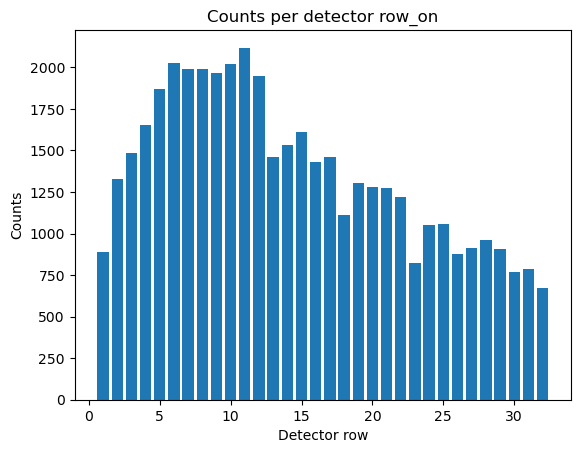

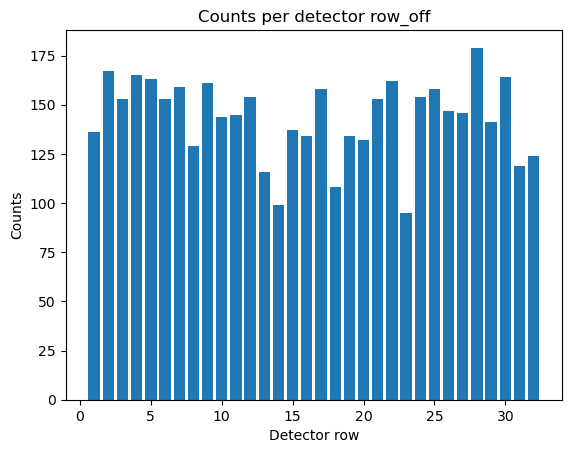

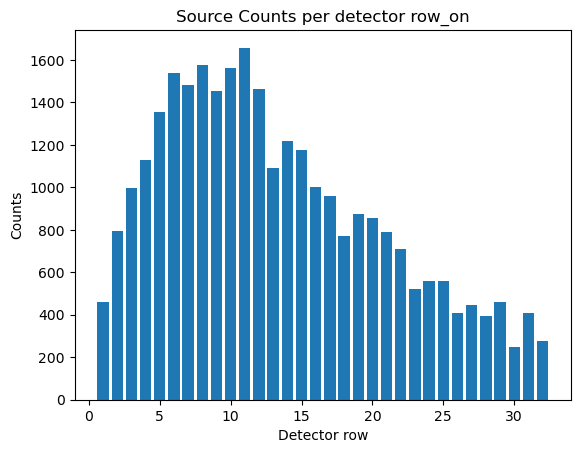

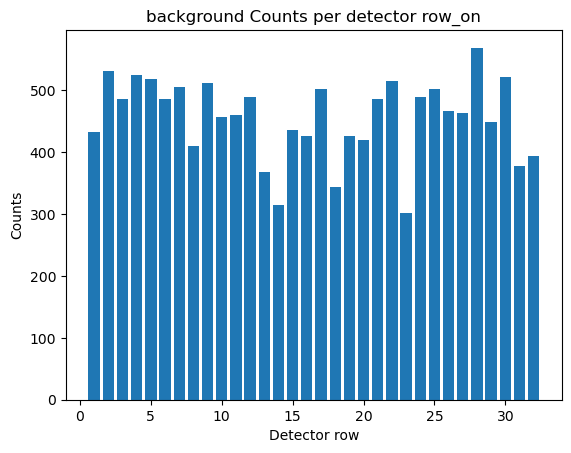

In [31]:
import matplotlib.pyplot as plt

rows_on = list(row_counts_on.keys())
rows_off = list(row_counts_off.keys())

counts_on  = np.array(list(row_counts_on.values()))
counts_off = np.array(list(row_counts_off.values()))

#nS = nOn - scale * nOff
counts_S = counts_on - scale * counts_off
counts_B = counts_on - counts_S

plt.figure()
plt.bar(rows_on, counts_on)
plt.xlabel("Detector row")
plt.ylabel("Counts")
plt.title("Counts per detector row_on")
plt.show()

plt.figure()
plt.bar(rows_off, counts_off)
plt.xlabel("Detector row")
plt.ylabel("Counts")
plt.title("Counts per detector row_off")
plt.show()

plt.figure()
plt.bar(rows_on, counts_S)
plt.xlabel("Detector row")
plt.ylabel("Counts")
plt.title("Source Counts per detector row_on")
plt.show()

plt.figure()
plt.bar(rows_off, counts_B)
plt.xlabel("Detector row")
plt.ylabel("Counts")
plt.title("background Counts per detector row_on")
plt.show()